**Lab2-DL: F2-TabPFN-neuro.ipynb** (BMED365) | Priority: 4 (advanced)

# 🧠 TabPFN in Neuroscience: Handwriting Analysis for Dementia Diagnostics

_From pen and paper to machine learning – a cost-effective approach to early dementia detection_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/F2-TabPFN-neuro.ipynb)


Last updated: 2025-12-26, A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

**This notebook uses TabPFN v2.5** – the latest version with support for up to 50,000 rows and 2,000 features.

> 📚 **Learning Objectives:** After completing this notebook you should be able to:
> - Understand how handwriting analysis can be used for dementia screening
> - Apply TabPFN on the DARWIN dataset for Alzheimer's classification
> - Compare the performance of different machine learning models
> - Discuss advantages and challenges of digital biomarkers
> - Reflect on future diagnostic possibilities

---

## 🏥 Clinical Context: Dementia and Early Diagnostics

### Dementia – A Growing Public Health Challenge

> **Did you know?**
> - Over 55 million people worldwide live with dementia today
> - Alzheimer's disease accounts for 60-70% of all dementia cases
> - Early diagnosis can provide 2-3 extra years of good quality of life through early intervention
> - The global cost of dementia care exceeds $1.3 trillion annually

### Current Diagnostic Challenges

| Challenge | Consequence |
|-----------|-------------|
| **Late diagnosis** | Many receive diagnosis only when the disease is moderate to severe |
| **Expensive examinations** | MRI/CT (~$500-1000), PET (~$1500), lumbar puncture (invasive) |
| **Accessibility** | Long waiting lists, especially in rural areas |
| **Subjective assessments** | Cognitive tests depend on the examiner's experience |

### Handwriting Analysis as a Biomarker

**Why handwriting?**

Handwriting is a complex cognitive-motor task that involves:
- **Planning** (prefrontal cortex)
- **Fine motor skills** (motor cortex, basal ganglia)
- **Visuospatial processing** (parietal lobe)
- **Memory** (hippocampus – particularly affected in Alzheimer's)

> 💡 **Clinical insight:** Changes in handwriting (micrographia, tremor, pause patterns) can occur **years before** clinical dementia diagnosis!

### Advantages of Handwriting-Based Screening

| Aspect | Handwriting Analysis | Traditional Imaging |
|--------|---------------------|---------------------|
| **Cost** | ~$10 (pen + paper + algorithm) | $500-1500 |
| **Accessibility** | Doctor's office, nursing home, home | Hospital with specialized equipment |
| **Invasiveness** | None | Varies (radiation, contrast, spinal fluid) |
| **Time** | 5-10 minutes | Hours to days |
| **Scalability** | Mass screening possible | Limited capacity |

### TabPFN for Medical Diagnostics

TabPFN v2.5 is ideal for this type of medical research because:
- **Small datasets**: DARWIN has only 174 patients – perfect for TabPFN
- **Many variables**: 451 handwriting features – well within TabPFN's capacity (2000 features)
- **Uncertainty estimates**: Important for clinical decision support
- **Rapid development**: No hyperparameter tuning = faster from research to clinic



### 🔬 TabPFN: Technical Background (optional)

> ⚠️ **For the interested:** This section is optional – you can skip to the practical part below.

#### Why has deep learning struggled with tabular data?

Traditionally, neural networks have underperformed on tabular data compared to tree-based methods (XGBoost, Random Forest). Reasons:
- Tabular data has heterogeneous features (different scales, categorical vs. numerical)
- Neural networks need large datasets to learn effectively
- Hyperparameter tuning is time-consuming and requires expertise

#### TabPFN's Solution: In-Context Learning

TabPFN uses the same principle as large language models – **in-context learning**:

1. **Pre-training on synthetic data**: The model is trained on ~130 million synthetic datasets
2. **No traditional training**: New data is treated as a "prompt" – a single forward pass
3. **Transformer architecture**: Bidirectional attention over features and patients

| Version | Max rows | Max features | News |
|---------|----------|--------------|------|
| v1 (2022) | 1,000 | 100 | Original version |
| v2 (2024) | 10,000 | 500 | Regression, improved scaling |
| **v2.5 (2025)** | **50,000** | **2,000** | Faster, more accurate |

## 🚀 Let's Get Started!

Welcome to the practical part of the notebook!

### Before You Start

**In Google Colab:**
1. Copy the notebook to your own Google Drive (File → Save a copy in Drive)
2. Enable GPU: Runtime → Change runtime type → GPU

**Locally:**
Use the `bmed365-2026` conda environment which already has TabPFN installed.

---

> 🔵 **Tip:** Enable the table of contents with the `☰` icon for better navigation.

---

*This notebook is based on work by [Lennart Purucker](https://github.com/LennartPurucker) and [Prior Labs](https://priorlabs.ai/).*

In [1]:
# This is a quick check of whether the notebook is currently running on Google Colaboratory
# as that makes some difference for the code below.
# We'll do this in every notebook of the course.

try:
    import google.colab
    # If this statement executes without error, you're in a Colab environment.
    is_colab = True
    print("Running in Google Colab.")
except ImportError:
    # An ImportError means you're not in a Colab environment.
    is_colab = False
    print("Not running in Google Colab.")

Not running in Google Colab.


# 📦 Installation

Run the cells below to install TabPFN v2.5 and required dependencies.

> ⚠️ **Note:** Restart the runtime after installation if Colab requests it.

---

## 🔐 IMPORTANT: Hugging Face Authentication for TabPFN v2.5

The TabPFN v2.5 models are **gated** on Hugging Face and require you to accept the license terms.

### One-time steps (done once):

1. **Create an account** at [huggingface.co](https://huggingface.co) (free)

2. **Accept the terms** by visiting: [huggingface.co/Prior-Labs/tabpfn_2_5](https://huggingface.co/Prior-Labs/tabpfn_2_5)
   - Click on "**Agree and access repository**"

3. **Log in via terminal**:
   ```bash
   huggingface-cli login
   ```
   - Get token from: [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)

> 💡 **Note:** You only need to do this once per machine. After logging in, the models will be downloaded automatically.

In [2]:
if is_colab:
    # ============================================================
    # INSTALLATION FOR GOOGLE COLAB
    # ============================================================
    
    # Install TabPFN v2.5 (latest version)
    %pip install --upgrade tabpfn tabpfn-extensions
    
    # Install PyTorch Geometric
    %pip install torch-geometric

    # Install hyperopt for hyperparameter optimization
    %pip install hyperopt

    # Install baseline models for comparison
    %pip install catboost xgboost
    
    # Install dataset libraries
    %pip install ucimlrepo shap
    
    print("✅ Installation complete!")
else:
    print("=" * 60)
    print("LOCAL EXECUTION")
    print("=" * 60)
    print("TabPFN should be installed via the bmed365-2026 conda environment.")
    print("If not, run: pip install --upgrade tabpfn tabpfn-extensions")
    print("=" * 60)

# Verify TabPFN version
try:
    import tabpfn
    tabpfn_version = getattr(tabpfn, '__version__', 'unknown')
    print(f"\n✅ TabPFN version: {tabpfn_version}")
    
    # Check if it's v2.x
    if tabpfn_version.startswith('2.'):
        print(f"   You are using TabPFN v2.x – supports up to 50,000 rows and 2,000 features!")
    elif tabpfn_version.startswith('1.'):
        print("   ⚠️ You are using TabPFN v1.x – consider upgrading to v2.5")
        print("   Run: pip install --upgrade tabpfn")
except ImportError:
    print("\n❌ TabPFN is not installed!")
    print("   Run: pip install tabpfn tabpfn-extensions")


LOCAL EXECUTION
TabPFN should be installed via the bmed365-2026 conda environment.
If not, run: pip install --upgrade tabpfn tabpfn-extensions

✅ TabPFN version: 6.2.0


**⚡ Restart the runtime now** (Runtime → Restart runtime)

### 📚 Required Imports

First, we import required libraries and suppress some harmless warnings.

> 💡 **Note:** You may see warnings about `pkg_resources` or similar. These are **not errors** – they are just libraries using older methods that will be updated in future versions. The code works perfectly fine.


In [3]:
# Suppress harmless deprecation warnings (for cleaner output)
import warnings
warnings.filterwarnings('ignore', message='.*pkg_resources.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Disable TabPFN telemetry (avoids PostHog errors)
import os
os.environ['TABPFN_NO_TELEMETRY'] = '1'

# Suppress logging from backoff/posthog
import logging
logging.getLogger('backoff').setLevel(logging.ERROR)
logging.getLogger('posthog').setLevel(logging.ERROR)

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded (telemetry disabled)")


✅ Libraries loaded (telemetry disabled)


#### 🖥️ GPU Acceleration (recommended)

TabPFN supports multiple accelerators:

| Platform | Accelerator | Device name |
|----------|-------------|-------------|
| **Google Colab** | NVIDIA GPU | `cuda` |
| **Linux/Windows** | NVIDIA GPU | `cuda` |
| **Apple Silicon** (M1/M2/M3/M4) | Metal | `mps` |
| **Without GPU** | CPU | `cpu` |

**Setup:**
* **Google Colab:** Runtime → Change runtime type → GPU
* **Apple Silicon:** Works automatically with MPS (Metal Performance Shaders)
* **NVIDIA:** Make sure CUDA is installed

> 💡 The notebook automatically detects the best available accelerator!

In [4]:
# ============================================================
# IMPORTS - Required libraries
# ============================================================

import os
import requests
from io import StringIO
from urllib.error import URLError

# Data processing and numerical operations
import pandas as pd
import numpy as np

# Scikit-learn: Datasets and evaluation
from sklearn.datasets import load_breast_cancer, load_diabetes, load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    roc_auc_score,
)

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay

# Datasets from OpenML
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown, Latex

# Baseline models for comparison
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

# PyTorch and graph networks
import torch
import torch_geometric

# SHAP for model interpretation
import shap

# ============================================================
# TabPFN - The main model we will explore!
# ============================================================
from tabpfn import TabPFNClassifier, TabPFNRegressor

# ============================================================
# AUTOMATIC DEVICE DETECTION (CUDA / MPS / CPU)
# ============================================================
def get_device():
    """
    Detects the best available accelerator.
    Priority: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU
    """
    if torch.cuda.is_available():
        return 'cuda'
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return 'mps'
    else:
        return 'cpu'

# Set DEVICE as global variable for use throughout the notebook
DEVICE = get_device()

# Display information about selected accelerator
print("=" * 60)
print("ACCELERATOR INFORMATION")
print("=" * 60)

if DEVICE == 'cuda':
    print(f"✅ NVIDIA GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif DEVICE == 'mps':
    print(f"✅ Apple Silicon (MPS) available")
    print(f"   Using Metal Performance Shaders for acceleration")
    print(f"   An M4 Max with 128 GB unified memory will provide excellent performance!")
else:
    print("⚠️ No GPU found – using CPU")
    print("   TabPFN will work, but slower on large datasets")

print(f"\n🎯 Selected device: '{DEVICE}'")
print("=" * 60)

ACCELERATOR INFORMATION
✅ Apple Silicon (MPS) available
   Using Metal Performance Shaders for acceleration
   An M4 Max with 128 GB unified memory will provide excellent performance!

🎯 Selected device: 'mps'


In [5]:
# ============================================================
# VERSION INFO AND DEVICE STATUS
# ============================================================
print("=" * 60)
print("LIBRARY VERSIONS")
print("=" * 60)
print(f"torch:           {torch.__version__}")
print(f"torch_geometric: {torch_geometric.__version__}")
print(f"shap:            {shap.__version__}")

print("\n" + "=" * 60)
print("ACCELERATOR STATUS")
print("=" * 60)
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"MPS available:   {torch.backends.mps.is_available()}")
print(f"Selected device: {DEVICE}")

# Display details depending on device
if DEVICE == 'cuda':
    print(f"\n🖥️ NVIDIA GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"   Memory: {props.total_memory / 1e9:.1f} GB")
elif DEVICE == 'mps':
    print(f"\n🍎 Apple Silicon with MPS acceleration")
    print(f"   Metal Performance Shaders enabled")
else:
    print(f"\n💻 Running on CPU")
print("=" * 60)

LIBRARY VERSIONS
torch:           2.6.0
torch_geometric: 2.7.0
shap:            0.49.1

ACCELERATOR STATUS
CUDA available:  False
MPS available:   True
Selected device: mps

🍎 Apple Silicon with MPS acceleration
   Metal Performance Shaders enabled


# 🧪 Practical Part: TabPFN for Neuroscience and Dementia Diagnostics

In this section, we will explore how TabPFN can be applied to real medical datasets. We focus primarily on the **DARWIN dataset** – a unique dataset that uses handwriting analysis to distinguish between Alzheimer's patients and healthy controls.

### Learning Objectives

After this section, you should be able to:
1. 🔍 Understand how TabPFN can be used on medical tabular data
2. 📊 Interpret model performance (ROC AUC, sensitivity, specificity)
3. 🧠 Reflect on clinical relevance and limitations
4. ⚖️ Discuss ethical aspects of AI-based diagnostics

### Structure

| Part | Dataset | Focus |
|------|---------|-------|
| **Main Part** | DARWIN (Alzheimer) | Handwriting analysis for dementia screening |
| Appendix A | Glioma | Brain tumor grading from genetic markers |
| Appendix B | Bonn EEG | Epileptic activity from brain signals |

---


Let's start by exploring the DARWIN dataset and see how TabPFN performs on this classification task.


## 🔬 Main Part: The DARWIN Dataset

### Handwriting Analysis for Early Alzheimer's Detection

**Why handwriting?**

Handwriting is a complex motor and cognitive task that requires:
- 🧠 **Cognition:** Planning, memory, language processing
- ✋ **Fine motor skills:** Precise control of hand and fingers
- 👁️ **Visuospatial processing:** Coordination between vision and movement

In Alzheimer's disease, these functions are affected early, often *before* noticeable memory problems. This makes handwriting a potential **early biomarker**.

### Advantages of Handwriting Analysis

| Advantage | Description |
|-----------|-------------|
| 💰 **Inexpensive** | Only pen, paper, and digitization |
| 🏠 **Accessible** | Can be performed at home or doctor's office |
| 😊 **Non-invasive** | No blood tests or scanning |
| ⏱️ **Fast** | Takes only minutes to complete |
| 📈 **Objective** | Quantifiable measurements |

---


### Dataset Description

| Property | Value |
|----------|-------|
| **Source** | UCI Machine Learning Repository |
| **Participants** | 174 (Alzheimer + healthy controls) |
| **Variables** | 451 handwriting features |
| **Task** | Binary classification |

**Variable types include:**
- Writing speed and acceleration
- Pen pressure
- Time spent on paper vs. in air
- Movement trajectories and angles

**Reference:** Cilia et al., *Engineering Applications of AI*, 2022. [DOI](https://doi.org/10.1016/j.engappai.2022.104822)

---


### 📋 Detailed Variable Description

The DARWIN dataset contains **451 variables** extracted from handwriting tasks. These variables capture different aspects of the handwriting process that are affected by neurological and cognitive function.

---

#### 🏃 Kinematic Variables (movement)

| Variable Group | Description | Clinical Significance |
|----------------|-------------|----------------------|
| **Velocity** | Average and maximum writing speed | Reduced in motor impairment, bradykinesia |
| **Acceleration** | Change in velocity over time | Reflects fine motor control |
| **Jerk** | Change in acceleration (third derivative) | High jerk = uneven movements, tremor |
| **Smoothness** | How smooth the movement is | Reduced in neurodegenerative diseases |

> 💡 **Neurological background:** In Alzheimer's disease, the basal ganglia and cerebellum are affected, which are central to movement control. This results in reduced speed and more uneven movements.

---

#### ⏱️ Temporal Variables (time)

| Variable | Description | Clinical Significance |
|----------|-------------|----------------------|
| **On-paper time** | Time the pen is in contact with paper | Increased = slower writing |
| **In-air time** | Time the pen is in the air between strokes | Increased = cognitive pauses, planning difficulties |
| **Total time** | Total time for the task | General processing speed |
| **In-air/On-paper ratio** | Ratio between air time and paper time | High ratio = more planning/hesitation |

> 💡 **Cognitive background:** "In-air time" often reflects **executive functions** – the ability to plan the next movement. Patients with dementia spend more time planning.

---

#### 💪 Pressure Variables (force)

| Variable | Description | Clinical Significance |
|----------|-------------|----------------------|
| **Average pressure** | Mean value of pen pressure | Reduced in muscle weakness |
| **Pressure standard deviation** | Variation in pressure | Increased = unstable control |
| **Maximum pressure** | Highest pressure value | Related to motor strength |
| **Pressure pattern** | How pressure changes through strokes | Abnormal in neuropathies |

> 💡 **Motor background:** Pressure variation reflects **fine motor coordination**. In dementia with Lewy bodies, parkinsonian features with reduced pressure are often seen.

---

#### 📐 Spatial Variables (shape and position)

| Variable | Description | Clinical Significance |
|----------|-------------|----------------------|
| **Stroke length** | Length of individual pen strokes | Shorter strokes in motor impairment |
| **Curvature** | Degree of bending in strokes | Abnormal in visuospatial impairment |
| **Direction changes** | Number of direction shifts | Increased in tremor or uncertainty |
| **Writing area** | Total area used on paper | Micrographia in Parkinson's |

> 💡 **Visuospatial background:** Alzheimer's patients often have **visuospatial impairment**, which affects the ability to organize writing on paper and maintain consistent size.

---

#### 🔄 Dynamic Variables (change over time)

| Variable | Description | Clinical Significance |
|----------|-------------|----------------------|
| **Velocity change** | How velocity changes through the task | Fatigue effect in neurodegeneration |
| **Pressure change** | How pressure changes over time | Exhaustion, loss of concentration |
| **Consistency** | How similar repeated movements are | Reduced in cognitive disorders |

---

#### 🧪 Task-Specific Variables

The DARWIN dataset includes several handwriting tasks:

| Task | What it tests | Example |
|------|---------------|---------|
| **Copying tasks** | Visual-motor integration | Copying geometric figures |
| **Dictation** | Auditory processing + motor skills | Writing words read aloud |
| **Free writing** | Language + executive functions | Writing a sentence |
| **Signature** | Over-learned motor program | Writing own name |

> 💡 **Diagnostic relevance:** Different tasks reveal different types of impairment. For example:
> - **Copying tasks** reveal visuospatial impairment (parietal dysfunction)
> - **Dictation** reveals auditory processing (temporal dysfunction)
> - **Signature** is often preserved longer because it is highly automated

---

#### 🧠 Connection Between Variables and Brain Regions

```
┌─────────────────────────────────────────────────────────────────┐
│                    THE BRAIN'S ROLE IN HANDWRITING              │
├──────────────────┬──────────────────────────────────────────────┤
│ Frontal cortex   │ Planning, sequencing (in-air time)           │
│ Parietal cortex  │ Visuospatial processing (curvature, area)    │
│ Motor cortex     │ Movement execution (velocity, pressure)      │
│ Cerebellum       │ Coordination, smoothness (smoothness, jerk)  │
│ Basal ganglia    │ Movement initiation (reaction time)          │
│ Temporal cortex  │ Language processing (dictation tasks)        │
└──────────────────┴──────────────────────────────────────────────┘
```

In Alzheimer's disease, early involvement of **hippocampus** and **parietal cortex** is typically seen, which explains why visuospatial variables are often affected early in the disease course.

---


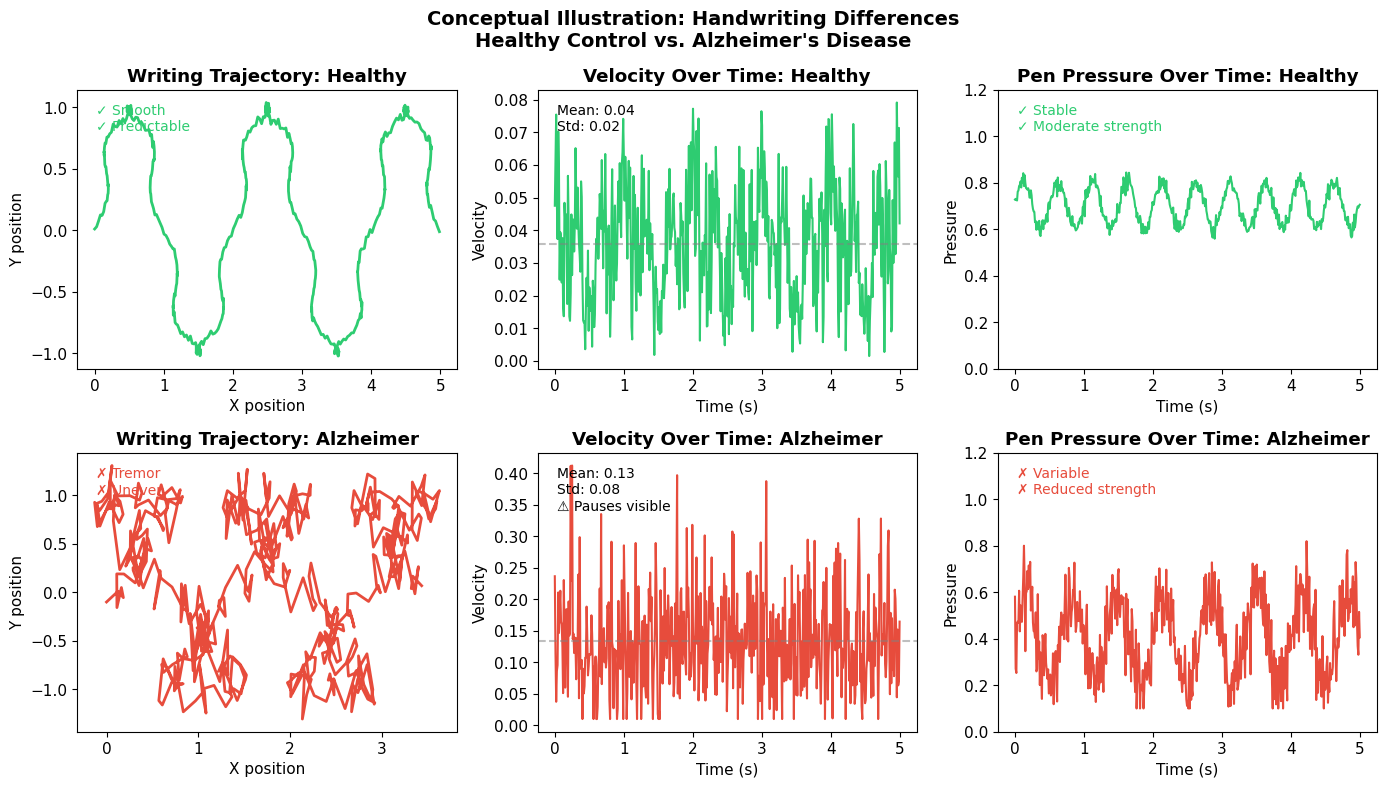


📊 The figure shows simulated kinematic data illustrating typical differences:
   • Healthy: Smooth movements, stable velocity, consistent pressure
   • Alzheimer: Tremor, velocity pauses (in-air time), variable pressure


In [6]:
# Conceptual illustration: Handwriting differences in dementia
# This is a simulated visualization based on known clinical characteristics

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects

np.random.seed(42)

def simulate_handwriting(text_type='healthy'):
    """Simulates kinematic handwriting data"""
    t = np.linspace(0, 10, 1000)
    
    if text_type == 'healthy':
        # Smooth, fast movement with little tremor
        x = t + 0.1 * np.sin(2 * np.pi * t * 3)  # Smooth progression
        y = np.sin(2 * np.pi * t * 0.5) + 0.02 * np.random.randn(len(t))  # Little noise
        velocity = np.abs(np.gradient(x)) + np.abs(np.gradient(y))
        pressure = 0.7 + 0.1 * np.sin(2 * np.pi * t * 2) + 0.02 * np.random.randn(len(t))
    else:
        # Slower, more uneven movement with tremor and pauses
        x = 0.7 * t + 0.3 * np.sin(2 * np.pi * t * 2) + 0.1 * np.sin(2 * np.pi * t * 15)  # Tremor
        y = np.sin(2 * np.pi * t * 0.5) + 0.15 * np.random.randn(len(t))  # More noise
        velocity = np.abs(np.gradient(x)) + np.abs(np.gradient(y))
        # Adding pauses (in-air time)
        pause_idx = np.random.choice(len(t), size=50, replace=False)
        velocity[pause_idx] = 0.01
        pressure = 0.4 + 0.2 * np.sin(2 * np.pi * t * 1.5) + 0.1 * np.random.randn(len(t))
        pressure = np.clip(pressure, 0.1, 1.0)
    
    return t, x, y, velocity, pressure

# Generate data
t_h, x_h, y_h, vel_h, pres_h = simulate_handwriting('healthy')
t_d, x_d, y_d, vel_d, pres_d = simulate_handwriting('dementia')

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Conceptual Illustration: Handwriting Differences\nHealthy Control vs. Alzheimer\'s Disease', 
             fontsize=14, fontweight='bold')

# Colors
color_healthy = '#2ecc71'
color_dementia = '#e74c3c'

# --- Row 1: Healthy ---
# Trajectory
axes[0, 0].plot(x_h[:500], y_h[:500], color=color_healthy, linewidth=2)
axes[0, 0].set_title('Writing Trajectory: Healthy', fontweight='bold')
axes[0, 0].set_xlabel('X position')
axes[0, 0].set_ylabel('Y position')
axes[0, 0].text(0.05, 0.95, '✓ Smooth\n✓ Predictable', transform=axes[0, 0].transAxes, 
                va='top', fontsize=10, color=color_healthy)

# Velocity
axes[0, 1].plot(t_h[:500], vel_h[:500], color=color_healthy, linewidth=1.5)
axes[0, 1].set_title('Velocity Over Time: Healthy', fontweight='bold')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Velocity')
axes[0, 1].axhline(np.mean(vel_h), color='gray', linestyle='--', alpha=0.5, label='Mean')
axes[0, 1].text(0.05, 0.95, f'Mean: {np.mean(vel_h):.2f}\nStd: {np.std(vel_h):.2f}', 
                transform=axes[0, 1].transAxes, va='top', fontsize=10)

# Pressure
axes[0, 2].plot(t_h[:500], pres_h[:500], color=color_healthy, linewidth=1.5)
axes[0, 2].set_title('Pen Pressure Over Time: Healthy', fontweight='bold')
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel('Pressure')
axes[0, 2].set_ylim(0, 1.2)
axes[0, 2].text(0.05, 0.95, '✓ Stable\n✓ Moderate strength', 
                transform=axes[0, 2].transAxes, va='top', fontsize=10, color=color_healthy)

# --- Row 2: Dementia ---
# Trajectory
axes[1, 0].plot(x_d[:500], y_d[:500], color=color_dementia, linewidth=2)
axes[1, 0].set_title('Writing Trajectory: Alzheimer', fontweight='bold')
axes[1, 0].set_xlabel('X position')
axes[1, 0].set_ylabel('Y position')
axes[1, 0].text(0.05, 0.95, '✗ Tremor\n✗ Uneven', transform=axes[1, 0].transAxes, 
                va='top', fontsize=10, color=color_dementia)

# Velocity
axes[1, 1].plot(t_d[:500], vel_d[:500], color=color_dementia, linewidth=1.5)
axes[1, 1].set_title('Velocity Over Time: Alzheimer', fontweight='bold')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Velocity')
axes[1, 1].axhline(np.mean(vel_d), color='gray', linestyle='--', alpha=0.5)
axes[1, 1].text(0.05, 0.95, f'Mean: {np.mean(vel_d):.2f}\nStd: {np.std(vel_d):.2f}\n⚠️ Pauses visible', 
                transform=axes[1, 1].transAxes, va='top', fontsize=10)

# Pressure
axes[1, 2].plot(t_d[:500], pres_d[:500], color=color_dementia, linewidth=1.5)
axes[1, 2].set_title('Pen Pressure Over Time: Alzheimer', fontweight='bold')
axes[1, 2].set_xlabel('Time (s)')
axes[1, 2].set_ylabel('Pressure')
axes[1, 2].set_ylim(0, 1.2)
axes[1, 2].text(0.05, 0.95, '✗ Variable\n✗ Reduced strength', 
                transform=axes[1, 2].transAxes, va='top', fontsize=10, color=color_dementia)

plt.tight_layout()
plt.savefig('handwriting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 The figure shows simulated kinematic data illustrating typical differences:")
print("   • Healthy: Smooth movements, stable velocity, consistent pressure")
print("   • Alzheimer: Tremor, velocity pauses (in-air time), variable pressure")


### 🎨 Visualization of Handwriting Differences

The figure above is a **conceptual illustration** based on known clinical characteristics of Alzheimer's disease. It shows:

| Measurement | Healthy Control | Alzheimer's Patient |
|-------------|-----------------|---------------------|
| **Writing trajectory** | Smooth, predictable | Uneven, tremor-affected |
| **Velocity** | Stable, fast | Variable, with pauses |
| **Pressure** | Consistent, moderate | Variable, often reduced |

> ⚠️ **Note:** This is simulated data for illustration purposes. Actual measurements from the DARWIN dataset will show similar but more complex patterns.

**References to actual handwriting studies:**
- Cilia et al. (2022): *Diagnosing Alzheimer's disease from handwriting*. Engineering Applications of AI. [DOI](https://doi.org/10.1016/j.engappai.2022.104822)
- Impedovo & Pirlo (2019): *Dynamic handwriting analysis for Alzheimer's disease*. Pattern Recognition Letters.

---


In [7]:
# !pip install ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo 

# Fetch the DARWIN dataset from UCI Machine Learning Repository
darwin = fetch_ucirepo(id=732) 

# Data (as pandas DataFrames)
X = darwin.data.features 
y = darwin.data.targets.values.ravel()  # Convert to 1D array 

# Metadata - convert to readable format
metadata_dict = {}
for key, value in darwin.metadata.items():
    # Handle nested structures
    if isinstance(value, (list, dict)):
        metadata_dict[key] = str(value)  # Convert complex objects to text
    else:
        metadata_dict[key] = value

# Create DataFrame with one row
metadata_df = pd.DataFrame([metadata_dict])

# Display transposed DataFrame for better readability
print("\nDataset Metadata:")
print(metadata_df.T)

# Display variable information
print("\nVariable Information:")
pd.DataFrame(darwin.variables)



Dataset Metadata:
                                                                          0
uci_id                                                                  732
name                                                                 DARWIN
repository_url               https://archive.ics.uci.edu/dataset/732/darwin
data_url                  https://archive.ics.uci.edu/static/public/732/...
abstract                  The DARWIN dataset includes handwriting data f...
area                                                    Health and Medicine
tasks                                                    ['Classification']
characteristics                                                 ['Tabular']
num_instances                                                           174
num_features                                                            451
feature_types                                                            []
demographics                                                         

,name,role,type,demographic,description,units,missing_values
0,ID,Feature,Categorical,None,None,None,no
1,air_time1,Feature,Integer,None,None,None,no
2,disp_index1,Feature,Categorical,None,None,None,no
3,gmrt_in_air1,Feature,Continuous,None,None,None,no
4,gmrt_on_paper1,Feature,Continuous,None,None,None,no
...,...,...,...,...,...,...,...
447,paper_time25,Feature,Integer,None,None,None,no
448,pressure_mean25,Feature,Continuous,None,None,None,no
449,pressure_var25,Feature,Continuous,None,None,None,no
450,total_time25,Feature,Integer,None,None,None,no


In [9]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
)
    
print("\nData split complete:")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
# Number of classes in training and test sets
print(f"Number of classes in training set: {len(np.unique(y_train))}")
print(f"Number of classes in test set: {len(np.unique(y_test))}")
# Class distribution in training and test sets
print(f"Class distribution in training set: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class distribution in test set: {dict(zip(*np.unique(y_test, return_counts=True)))}")



Data split complete:
Training set shape: (139, 451)
Test set shape: (35, 451)
Number of classes in training set: 2
Number of classes in test set: 2
Class distribution in training set: {'H': np.int64(68), 'P': np.int64(71)}
Class distribution in test set: {'H': np.int64(17), 'P': np.int64(18)}


In [10]:
print("\nText columns:")
print(X.select_dtypes(include=['object']).columns)


Text columns:
Index(['ID'], dtype='object')


In [11]:
%%time
# Train and evaluate TabPFN
classifier = TabPFNClassifier(random_state=42, device=DEVICE)  # Uses automatically detected device
classifier.fit(X_train, y_train)
y_pred = classifier.predict_proba(X_test)

# Calculate ROC AUC with multiclass handling
if len(np.unique(y)) > 2:
    # For multiclass ROC AUC, use 'ovr' (one-vs-rest) approach
    score = roc_auc_score(y_test, y_pred, multi_class='ovr', average='macro')
else:
    # For binary classification
    score = roc_auc_score(y_test, y_pred[:, 1])

print(f"TabPFN ROC AUC: {score:.4f}")

# Also print accuracy for easier interpretation when using multiclass
accuracy = accuracy_score(y_test, classifier.predict(X_test))
print(f"TabPFN Accuracy: {accuracy:.4f}")

# Print confusion matrix
from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, classifier.predict(X_test)))

TabPFN ROC AUC: 0.8464
TabPFN Accuracy: 0.6857

Confusion Matrix:
[[16  1]
 [10  8]]
CPU times: user 9.12 s, sys: 2.25 s, total: 11.4 s
Wall time: 12.3 s


### 📊 Interpretation of TabPFN on DARWIN Dataset (Alzheimer vs. Healthy)

#### Results Overview

| Metric | Value | Assessment |
|--------|-------|------------|
| **ROC AUC** | 0.8464 | ✅ Good discriminative ability |
| **Accuracy** | 68.57% | ⚠️ Moderate |
| **Training time** | ~10 sec | ✅ Fast |

#### Confusion Matrix Explained

```
                    Predicted
                 Healthy  Alzheimer
Actual  Healthy     16      1
        Alzheimer   10      8
```

| Measure | Calculation | Value | Clinical Significance |
|---------|-------------|-------|----------------------|
| **Specificity** | 16/(16+1) | **94%** | Very few healthy misdiagnosed ✅ |
| **Sensitivity** | 8/(8+10) | **44%** | Many Alzheimer's patients not detected ⚠️ |
| **PPV** (Positive predictive value) | 8/(8+1) | **89%** | High confidence with positive test |
| **NPV** (Negative predictive value) | 16/(16+10) | **62%** | Moderate confidence with negative test |

#### ⚠️ Clinical Concern

> **10 out of 18 Alzheimer's patients were classified as healthy!**
> 
> In a screening tool for dementia, low sensitivity is problematic – we want to catch as many sick patients as possible, even if it means some false positives. An undetected Alzheimer's patient loses the opportunity for early intervention.

#### Possible Reasons for the Results

1. **Small dataset** – Only 174 participants total, ~35 in test set
2. **Imbalanced classes** – Possible skewed distribution in training data
3. **Handwriting variation** – Large individual variation in writing patterns
4. **Disease stage** – Early Alzheimer's may have subtle changes

#### Clinical Perspective

> 💡 **Important:** A ROC AUC of 0.85 indicates that the model *can* distinguish between groups, but the chosen threshold gives low sensitivity. In clinical practice, one could:
> - Adjust the classification threshold for higher sensitivity (at the expense of specificity)
> - Use the model as a *supplementary* tool, not as the only diagnostic
> - Combine with other biomarkers for better accuracy

---


In [12]:
# Model comparison for DARWIN dataset (Alzheimer vs. Healthy)
# Compare different machine learning models with 5-fold cross-validation

# Use X directly (DARWIN has no text columns that need to be removed)
X_numeric = X.select_dtypes(include=[np.number])

# Check that we have correct data
print(f"X_numeric shape: {X_numeric.shape}")
print(f"y shape: {y.shape if hasattr(y, 'shape') else len(y)}")

# Encode target variable (ensures 1D array)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Verify consistency
assert len(X_numeric) == len(y_encoded), f"Error: X has {len(X_numeric)} samples, y has {len(y_encoded)}"
print(f"✅ Data is consistent: {len(X_numeric)} samples")

# Define models for comparison
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'TabPFN': TabPFNClassifier(random_state=42, device=DEVICE),
    'XGBoost': XGBClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Calculate scores with cross-validation
scoring = 'roc_auc_ovr' if len(np.unique(y_encoded)) > 2 else 'roc_auc'
print(f"\nRunning 5-fold cross-validation with {scoring}...")

scores = {name: cross_val_score(model, X_numeric, y_encoded, cv=5, scoring=scoring, n_jobs=1, verbose=1).mean()
          for name, model in models.items()}

# Display results
df = pd.DataFrame(list(scores.items()), columns=['Model', 'ROC AUC'])
print("\nCross-validation results:")
df


X_numeric shape: (174, 450)
y shape: (174,)
✅ Data is consistent: 174 samples

Running 5-fold cross-validation with roc_auc...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   16.4s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.7s finished



Cross-validation results:


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   13.6s finished


,Model,ROC AUC
0,Random Forest,0.881161
1,TabPFN,0.913187
2,XGBoost,0.880546
3,CatBoost,0.908304


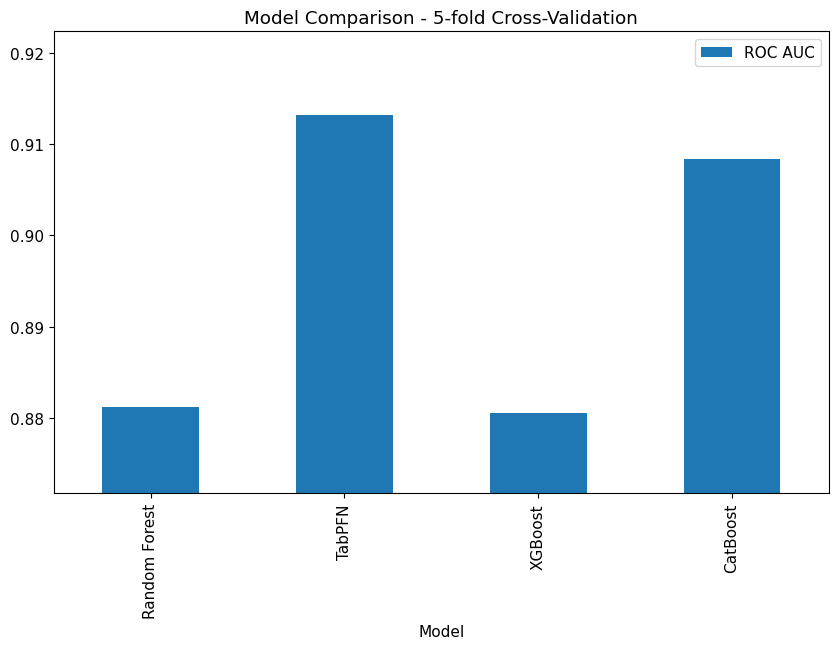

In [13]:
# Plot results
df = pd.DataFrame(list(scores.items()), columns=['Model', 'ROC AUC'])
ax = df.plot(x='Model', y='ROC AUC', kind='bar', figsize=(10, 6))
ax.set_ylim(df['ROC AUC'].min() * 0.99, df['ROC AUC'].max() * 1.01)
ax.set_title('Model Comparison - 5-fold Cross-Validation')

plt.show()

---

## 📎 Appendix A: Glioma Dataset (supplementary example)

> 💡 **Purpose:** Demonstrate TabPFN on another medical domain – brain tumor classification based on genetic markers.

### Clinical Background: Gliomas and Precision Diagnostics

**Gliomas** are the most common primary brain tumors and account for approximately 30% of all brain tumors. Accurate grading is critical for treatment selection and prognosis.

#### Classification (WHO 2021)

| Type | Description | 5-year survival | Treatment |
|------|-------------|-----------------|-----------|
| **LGG** (Low-grade, grade 2-3) | Slower growth, diffuse infiltration | 50-90% | Surgery ± radiation |
| **GBM** (Glioblastoma, grade 4) | Very aggressive, rapid growth | <10% | Multimodal (surgery + radiation + chemo) |

#### Molecular Markers and Their Significance

| Marker | Function | Clinical Significance |
|--------|----------|----------------------|
| **IDH1/2 mutation** | Metabolic enzyme | Mutation = better prognosis, common in LGG |
| **PTEN** | Tumor suppressor | Loss = more aggressive disease |
| **ATRX** | Telomere regulation | Loss = alternative telomere lengthening |
| **CIC** | Transcription regulator | Mutation = better prognosis in oligodendrogliomas |
| **1p/19q co-deletion** | Chromosomal change | Indicates oligodendroglioma, good prognosis |

> 🏥 **Clinical relevance:** Molecular diagnostics has revolutionized glioma treatment. IDH mutation status is now mandatory for classification (WHO 2021). TabPFN can help identify patterns in these complex datasets.

### Dataset Description

- **Source:** TCGA (The Cancer Genome Atlas) via UCI ML Repository
- **Patients:** ~800 with confirmed glioma
- **Variables:** Clinical (age, gender) + genetic mutations
- **Task:** Classify LGG vs. GBM

---


Let's see how TabPFN performs on this dataset with genetic markers.


In [15]:
from ucimlrepo import fetch_ucirepo 
  
# Fetch the glioma dataset 
glioma_grading_clinical_and_mutation_features = fetch_ucirepo(id=759) 
  
# Data (as pandas DataFrames) 
X = glioma_grading_clinical_and_mutation_features.data.features 
y = glioma_grading_clinical_and_mutation_features.data.targets.values.ravel()  # Convert to 1D array 

  
# Metadata as pandas dataframe
# Convert metadata to a more manageable format
metadata_dict = {}
for key, value in glioma_grading_clinical_and_mutation_features.metadata.items():
    # Handle potential nested structures
    if isinstance(value, (list, dict)):
        metadata_dict[key] = str(value)  # Convert complex objects to string
    else:
        metadata_dict[key] = value

# Create DataFrame with a single row
metadata_df = pd.DataFrame([metadata_dict])

# Display the transposed DataFrame for better readability
print("\nDataset Metadata:")
print(metadata_df.T)

# Also display the variable information
print("\nVariable Information:")
pd.DataFrame(glioma_grading_clinical_and_mutation_features.variables)
# Metadata 
print(glioma_grading_clinical_and_mutation_features.metadata) 
  
# Variable information 
glioma_grading_clinical_and_mutation_features.variables 


Dataset Metadata:
                                                                          0
uci_id                                                                  759
name                          Glioma Grading Clinical and Mutation Features
repository_url            https://archive.ics.uci.edu/dataset/759/glioma...
data_url                  https://archive.ics.uci.edu/static/public/759/...
abstract                  Gliomas are the most common primary tumors of ...
area                                                    Health and Medicine
tasks                                           ['Classification', 'Other']
characteristics                                 ['Tabular', 'Multivariate']
num_instances                                                           839
num_features                                                             23
feature_types                            ['Real', 'Categorical', 'Integer']
demographics                                      ['Gender', 'Age', '

,name,role,type,demographic,description,units,missing_values
0,Grade,Target,Categorical,None,"Glioma grade class information (0 = ""LGG""; 1 =...",N/A,no
1,Gender,Feature,Categorical,Gender,"Gender (0 = ""male""; 1 = ""female"")",N/A,no
2,Age_at_diagnosis,Feature,Continuous,Age,Age at diagnosis with the calculated number of...,years,no
3,Race,Feature,Categorical,Race,"Race (0 = ""white""; 1 = ""black or african Ame...",N/A,no
4,IDH1,Feature,Categorical,None,isocitrate dehydrogenase (NADP(+))1 (0 = NOT_M...,N/A,no
5,TP53,Feature,Categorical,None,tumor protein p53 (0 = NOT_MUTATED; 1 = MUTATED),N/A,no
6,ATRX,Feature,Categorical,None,ATRX chromatin remodeler (0 = NOT_MUTATED; 1 =...,N/A,no
7,PTEN,Feature,Categorical,None,phosphatase and tensin homolog (0 = NOT_MUTATE...,N/A,no
8,EGFR,Feature,Categorical,None,epidermal growth factor receptor (0 = NOT_MUTA...,N/A,no
9,CIC,Feature,Categorical,None,capicua transcriptional repressor (0 = NOT_MUT...,N/A,no


In [16]:
print("\nText columns:")
print(X.select_dtypes(include=['object']).columns)


Text columns:
Index(['Race'], dtype='object')


In [17]:
X_numeric = X.drop(columns=['Race'])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
)
    
print("\nData split complete:")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
# Number of classes in training and test sets
print(f"Number of classes in training set: {len(np.unique(y_train))}")
print(f"Number of classes in test set: {len(np.unique(y_test))}")
# Class distribution in training and test sets
print(f"Class distribution in training set: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class distribution in test set: {dict(zip(*np.unique(y_test, return_counts=True)))}")



Data split complete:
Training set shape: (671, 22)
Test set shape: (168, 22)
Number of classes in training set: 2
Number of classes in test set: 2
Class distribution in training set: {np.int64(0): np.int64(389), np.int64(1): np.int64(282)}
Class distribution in test set: {np.int64(0): np.int64(98), np.int64(1): np.int64(70)}


In [18]:
%%time
# Train and evaluate TabPFN
classifier = TabPFNClassifier(random_state=42, device=DEVICE) # , ignore_pretraining_limits=True) if more than 500 samples
classifier.fit(X_train, y_train)
y_pred = classifier.predict_proba(X_test)

# Calculate ROC AUC with multiclass handling
if len(np.unique(y)) > 2:
    # For multiclass ROC AUC, use 'ovr' (one-vs-rest) approach
    score = roc_auc_score(y_test, y_pred, multi_class='ovr', average='macro')
else:
    # For binary classification
    score = roc_auc_score(y_test, y_pred[:, 1])

print(f"TabPFN ROC AUC: {score:.4f}")

# Also print accuracy for easier interpretation when using multiclass
accuracy = accuracy_score(y_test, classifier.predict(X_test))
print(f"TabPFN Accuracy: {accuracy:.4f}")

# Print confusion matrix
from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, classifier.predict(X_test)))

TabPFN ROC AUC: 0.9278
TabPFN Accuracy: 0.8452

Confusion Matrix:
[[81 17]
 [ 9 61]]
CPU times: user 8.34 s, sys: 1.78 s, total: 10.1 s
Wall time: 9.86 s


In [19]:
# Compare different machine learning models by training each of them multiple times
# on different parts of the data and calculating the average of performance scores for
# a more reliable performance estimate


# Assuming X is your feature DataFrame and y is your target
# First, let's check the data types
print("Data types in X_numeric:")
print(X_numeric.dtypes)

# Remove or encode string columns
# Option 1: Remove string columns
#X_numeric = X.select_dtypes(include=[np.number])

# Option 2: Encode string columns
# X_encoded = X.copy()
# for column in X.select_dtypes(include=['object']):
#     le = LabelEncoder()
#     X_encoded[column] = le.fit_transform(X_encoded[column])

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Try cross-validation with numeric data
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'TabPFN': TabPFNClassifier(random_state=42, device=DEVICE), #,device=DEVICE),
    'XGBoost': XGBClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Calculate scores
scoring = 'roc_auc_ovr' if len(np.unique(y)) > 2 else 'roc_auc'
scores = {name: cross_val_score(model, X_numeric, y_encoded, cv=5, scoring=scoring, n_jobs=-1, verbose=1).mean()
          for name, model in models.items()}

# Plot results
df = pd.DataFrame(list(scores.items()), columns=['Model', 'ROC AUC'])
print("\nCross-validation results:")
df

Data types in X_numeric:
Gender                int64
Age_at_diagnosis    float64
IDH1                  int64
TP53                  int64
ATRX                  int64
PTEN                  int64
EGFR                  int64
CIC                   int64
MUC16                 int64
PIK3CA                int64
NF1                   int64
PIK3R1                int64
FUBP1                 int64
RB1                   int64
NOTCH1                int64
BCOR                  int64
CSMD3                 int64
SMARCA4               int64
GRIN2A                int64
IDH2                  int64
FAT4                  int64
PDGFRA                int64
dtype: object


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.



Cross-validation results:


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s finished


,Model,ROC AUC
0,Random Forest,0.896077
1,TabPFN,0.922849
2,XGBoost,0.900778
3,CatBoost,0.916516


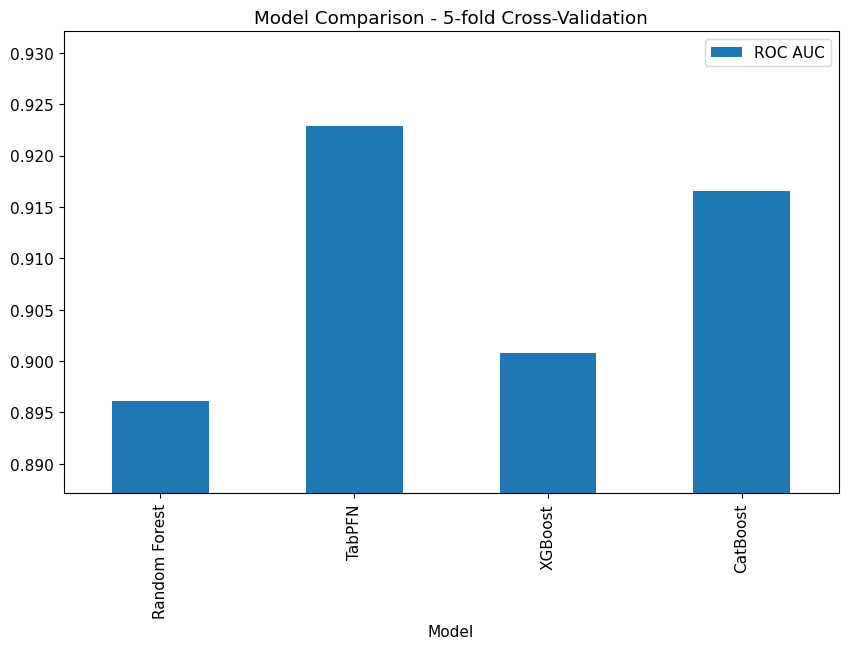

In [20]:
# Plot results
df = pd.DataFrame(list(scores.items()), columns=['Model', 'ROC AUC'])
ax = df.plot(x='Model', y='ROC AUC', kind='bar', figsize=(10, 6))
ax.set_ylim(df['ROC AUC'].min() * 0.99, df['ROC AUC'].max() * 1.01)
ax.set_title('Model Comparison - 5-fold Cross-Validation')

plt.show()

### 📊 Interpretation of Model Comparison (Glioma)

#### What do the results tell us?

| Observation | Meaning |
|-------------|---------|
| **High ROC AUC (~0.90+)** | Genetic markers distinguish well between tumor types |
| **TabPFN competitive** | Achieves good performance without hyperparameter tuning |
| **Consistency between models** | The signal in the data is robust and reliable |

#### Clinical Context

Molecular classification of gliomas is **already established clinical practice** (WHO 2021 classification). This dataset demonstrates that:

1. **AI can learn biological patterns** - Models capture known relationships
2. **Potential for decision support** - Can assist pathologists in difficult cases
3. **Integration of multiple markers** - AI can combine information effectively

> 💡 **Practical application:** Such models can be useful in situations where:
> - Tissue samples are limited
> - Rapid screening is needed
> - Complex marker profiles need to be interpreted

---


In [21]:
list(X_numeric.columns)

['Gender',
 'Age_at_diagnosis',
 'IDH1',
 'TP53',
 'ATRX',
 'PTEN',
 'EGFR',
 'CIC',
 'MUC16',
 'PIK3CA',
 'NF1',
 'PIK3R1',
 'FUBP1',
 'RB1',
 'NOTCH1',
 'BCOR',
 'CSMD3',
 'SMARCA4',
 'GRIN2A',
 'IDH2',
 'FAT4',
 'PDGFRA']

In [22]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Number of variables: 22

Training TabPFN model...

Calculating SHAP values for 15 samples...
(This may take 1-3 minutes depending on hardware)
X_test_subset shape: (15, 22)


  0%|          | 0/15 [00:00<?, ?it/s]


SHAP output type: <class 'numpy.ndarray'>
SHAP values shape: (15, 22, 2)

shap_vals shape: (15, 22, 2)
mean_abs_shap length: 44
feature_names length: 22
Using 22 features

📊 Top 10 most important variables:
  1. PTEN: 0.2965
  2. ATRX: 0.2965
  3. TP53: 0.0672
  4. IDH1: 0.0672
  5. EGFR: 0.0549
  6. CIC: 0.0549
  7. PIK3R1: 0.0459
  8. NF1: 0.0459
  9. MUC16: 0.0362
  10. PIK3CA: 0.0362


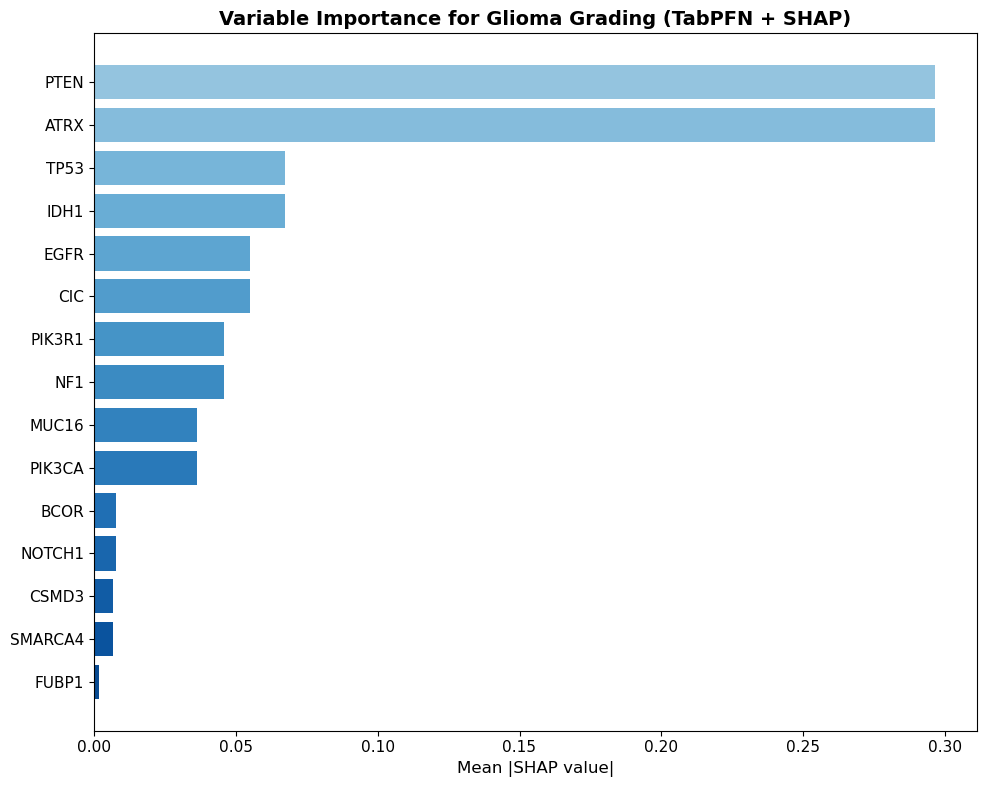


✅ SHAP analysis complete!
CPU times: user 1min 23s, sys: 21.5 s, total: 1min 45s
Wall time: 1min 28s


In [23]:
%%time
# SHAP analysis for variable importance (Glioma dataset)
# SHAP explains how each variable contributes to model predictions

import numpy as np
import pandas as pd
from tabpfn import TabPFNClassifier
import shap
import matplotlib.pyplot as plt

# Prepare data
feature_names = list(X_numeric.columns)
n_features = len(feature_names)
print(f"Number of variables: {n_features}")

# Train TabPFN model
print("\nTraining TabPFN model...")
clf = TabPFNClassifier(device=DEVICE, random_state=42)
clf.fit(X_train, y_train)

# Calculate SHAP values
n_samples = min(15, len(X_test))
print(f"\nCalculating SHAP values for {n_samples} samples...")
print("(This may take 1-3 minutes depending on hardware)")

# Use KernelExplainer
background = shap.kmeans(X_train, 10)
explainer = shap.KernelExplainer(clf.predict_proba, background)

# Get test data as numpy array
X_test_subset = X_test.iloc[:n_samples].values if hasattr(X_test, 'iloc') else X_test[:n_samples]
print(f"X_test_subset shape: {X_test_subset.shape}")

shap_values = explainer.shap_values(X_test_subset)

# Debug: Display shapes
print(f"\nSHAP output type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    for idx, sv in enumerate(shap_values):
        print(f"  Class {idx} shape: {np.array(sv).shape}")
    # For binary classification, use class 1 (GBM)
    shap_vals = np.array(shap_values[1])
else:
    print(f"SHAP values shape: {np.array(shap_values).shape}")
    shap_vals = np.array(shap_values)

print(f"\nshap_vals shape: {shap_vals.shape}")

# Calculate feature importance (mean absolute SHAP)
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

# Flatten and ensure 1D
mean_abs_shap = np.array(mean_abs_shap).flatten()
print(f"mean_abs_shap length: {len(mean_abs_shap)}")
print(f"feature_names length: {len(feature_names)}")

# Match lengths
min_len = min(len(mean_abs_shap), len(feature_names))
mean_abs_shap_trimmed = mean_abs_shap[:min_len]
feature_names_trimmed = feature_names[:min_len]

print(f"Using {min_len} features")

# Create lists explicitly
variable_list = list(feature_names_trimmed)
importance_list = list(mean_abs_shap_trimmed)

# Sort manually
sorted_indices = np.argsort(importance_list)[::-1]
variable_sorted = [variable_list[i] for i in sorted_indices]
importance_sorted = [importance_list[i] for i in sorted_indices]

print("\n📊 Top 10 most important variables:")
for j in range(min(10, len(variable_sorted))):
    print(f"  {j+1}. {variable_sorted[j]}: {importance_sorted[j]:.4f}")

# Plot bar chart
plt.figure(figsize=(10, 8))
top_n = min(15, len(variable_sorted))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
y_pos = range(top_n)
plt.barh(y_pos, importance_sorted[:top_n][::-1], color=colors)
plt.yticks(y_pos, variable_sorted[:top_n][::-1])
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.title('Variable Importance for Glioma Grading (TabPFN + SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ SHAP analysis complete!")


### 🔍 Interpretation of SHAP Results

**How to read the variable importance figure:**

| Element | Meaning |
|---------|---------|
| **Y-axis** | Genetic markers and clinical variables |
| **X-axis** | Mean |SHAP value| – how much the variable affects the prediction |
| **Bar length** | Longer bar = more important variable for the model |
| **Ranking** | Most important variables at top |

#### Clinical interpretation of top variables:

| Variable | Function | Clinical Significance |
|----------|----------|----------------------|
| **PTEN** | Tumor suppressor gene | Loss associated with aggressive GBM |
| **ATRX** | Telomere regulation | Mutation common in low-grade gliomas |
| **TP53** | "Guardian of the genome" | Mutation = increased tumorigenicity |
| **IDH1** | Metabolic enzyme | Mutation = better prognosis (common in LGG) |
| **EGFR** | Growth factor receptor | Amplification common in GBM |
| **CIC** | Transcription regulator | Mutation = better prognosis |

> 💡 **Main finding:** The model weights **PTEN** and **ATRX** most strongly, followed by classic glioma markers like **TP53** and **IDH1**. This aligns well with established neuro-oncology knowledge.

> 🧬 **Clinical validation:** That the AI model identifies the same markers used in WHO 2021 classification increases confidence in the model's biological relevance.


In [24]:
# Optional: Detailed SHAP analysis
# Uncomment lines below to run more detailed analyses

# Force plot for single patient
# shap.force_plot(explainer.expected_value[1], shap_vals[0], X_test.iloc[0], feature_names=feature_names)

# Dependence plot for most important variable
# shap.dependence_plot(0, shap_vals, X_test[:n_samples], feature_names=feature_names)

print("✅ SHAP analysis complete")
print("For more detailed analyses, see the TabPFN documentation")


✅ SHAP analysis complete
For more detailed analyses, see the TabPFN documentation


---

## 📎 Appendix B: Bonn EEG Dataset (supplementary example)

> 💡 **Purpose:** Demonstrate TabPFN on time series data converted to statistical features – epilepsy detection from EEG signals.

### Clinical Background: Epilepsy and EEG Diagnostics

**Epilepsy** affects approximately 1% of the population and is characterized by recurrent unprovoked seizures. EEG (electroencephalography) is the gold standard for diagnostics.

#### What does EEG show?

| Condition | EEG Characteristics | Description |
|-----------|---------------------|-------------|
| **Normal** | Alpha rhythm (8-12 Hz) | Regular background activity |
| **Interictal** | Sharp waves, spikes | Epileptiform activity between seizures |
| **Ictal (seizure)** | Rhythmic activity, high amplitude | Active epileptic activity |

#### Challenges in Clinical Practice

| Challenge | Consequence | AI Solution |
|-----------|-------------|-------------|
| **Time-consuming** | Long wait for interpretation | Automatic screening |
| **Expert-dependent** | Limited access in rural areas | Decision support |
| **Subjective** | Inter-rater variability | Consistent evaluation |
| **Large data volumes** | 24-hour EEG = millions of data points | Efficient filtering |

### The Bonn Dataset

This classic dataset (Andrzejak et al., 2001) consists of:

| Set | Description | Number | Condition |
|-----|-------------|--------|-----------|
| **A** | Healthy, eyes open | 100 segments | Normal |
| **B** | Healthy, eyes closed | 100 segments | Normal |
| **C** | Epilepsy, hippocampus (interictal) | 100 segments | Interictal |
| **D** | Epilepsy, epileptogenic zone (interictal) | 100 segments | Interictal |
| **E** | Epilepsy, during seizure (ictal) | 100 segments | Ictal |

**Technical details:**
- Sampling frequency: 173.6 Hz
- Segment length: 23.6 seconds (4096 data points)
- Recording: Surface EEG and depth electrodes

### From Time Series to Tabular Data

To use TabPFN, we convert EEG time series to **statistical features**:

| Feature Category | Examples | What it captures |
|------------------|----------|------------------|
| **Statistical** | Mean, std, skewness, kurtosis | Signal distribution |
| **Frequency** | Power in different bands (alpha, beta, etc.) | Oscillatory activity |
| **Entropy** | Sample entropy, spectral entropy | Signal complexity/irregularity |
| **Time domain** | Zero-crossings, line length | Signal shape and variability |

> 🧠 **Why this works:** Epileptic activity has distinct statistical signatures – higher amplitude, altered frequency spectrum, and reduced complexity during seizures.

---


### Dataset Overview

| Set | Content | Number of segments |
|-----|---------|-------------------|
| A, B | Healthy individuals | 200 |
| C, D, E | Epilepsy patients | 300 |

Each segment is 23.6 seconds of EEG data sampled at 173.6 Hz.


### Usage Instructions

To run the EEG example:

1. **Download the data** from [Bonn University](https://www.upf.edu/web/ntsa/downloads)
2. **Extract** the ZIP files to the `bonn_eeg_data/` folder
3. **Run the cells** below

> ⚠️ **Note:** This is a supplementary example. If you don't have access to the data, you can skip this section.

**References:**
- Andrzejak et al., Physical Review E, 2001
- [GitHub: hctsaTutorial_BonnEEG](https://github.com/benfulcher/hctsaTutorial_BonnEEG)

---


**References**

[1] Bonn EEG time series - UPF download page, [link](https://www.upf.edu/web/ntsa/downloads/-/asset_publisher/xvT6E4pczrBw/content/2001-indications-of-nonlinear-deterministic-and-finite-dimensional-structures-in-time-series-of-brain-electrical-activity-dependence-on-recording-regi)

[2] benfulcher/hctsaTutorial_BonnEEG: hctsa tutorial with the Bonn EEG dataset, [GitHub](https://github.com/benfulcher/hctsaTutorial_BonnEEG)


In [27]:
# If Colab, fetch EEG data and place in bonn_eeg_data folder
if is_colab:
    # Create folders
    !mkdir -p bonn_eeg_data/setA bonn_eeg_data/setE
    
    # Download and extract normal EEG data (Set A)
    !wget -O bonn_eeg_data/setA.zip https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab2-DL/data/bonn_eeg_data/setA.zip
    !unzip -j bonn_eeg_data/setA.zip -d bonn_eeg_data/setA/
    !rm bonn_eeg_data/setA.zip
    
    # Download and extract seizure EEG data (Set E)
    !wget -O bonn_eeg_data/setE.zip https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab2-DL/data/bonn_eeg_data/setE.zip
    !unzip -j bonn_eeg_data/setE.zip -d bonn_eeg_data/setE/
    !rm bonn_eeg_data/setE.zip   

# Verify data structure
data_dir='bonn_eeg_data'
required_dirs = ['setA', 'setE']
for subdir in required_dirs:
    if not os.path.exists(os.path.join(data_dir, subdir)):
        print(f"Error: Missing {subdir} directory")
    else:
        print(f"Directory {subdir} exists")

dataset_name = 'Bonn EEG data'

Error: Missing setA directory
Error: Missing setE directory


In [28]:
import os
import zipfile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def setup_bonn_eeg_data(data_dir='../data/bonn_eeg_data'):
    """
    Extract and prepare Bonn EEG data.
    """
    # Check if zip files exist
    zip_files = {
        'setA': os.path.join(data_dir, 'setA.zip'),
        'setE': os.path.join(data_dir, 'setE.zip')
    }
    
    for set_name, zip_path in zip_files.items():
        extract_dir = os.path.join(data_dir, set_name)
        
        if os.path.exists(zip_path) and not os.path.exists(extract_dir):
            print(f"📦 Extracting {zip_path}...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(data_dir)
            print(f"   ✅ Extracted to {extract_dir}")
        elif os.path.exists(extract_dir):
            print(f"✅ {set_name} already extracted")
        else:
            print(f"⚠️ Cannot find {zip_path}")

def load_bonn_eeg_data(data_dir='../data/bonn_eeg_data', n_samples=100):
    """
    Load Bonn EEG dataset.
    
    Returns:
        X: Feature matrix (statistical features from EEG)
        y: Class labels (0=Normal, 1=Seizure)
        dataset_name: Name of the dataset
    """
    
    # Extract data first if necessary
    setup_bonn_eeg_data(data_dir)
    
    # Define classes
    classes = {
        'setA': ('Normal', 0),
        'setE': ('Seizure', 1)
    }
    
    X_list = []
    y_list = []
    
    for set_name, (label_name, label) in classes.items():
        set_path = os.path.join(data_dir, set_name)
        
        if not os.path.exists(set_path):
            print(f"⚠️ {set_path} does not exist")
            continue
        
        # Find txt files
        files = sorted([f for f in os.listdir(set_path) if f.endswith('.txt')])[:n_samples]
        print(f"📂 {set_name}: Found {len(files)} files")
        
        for file in files:
            filepath = os.path.join(set_path, file)
            try:
                signal = np.loadtxt(filepath)
                features = extract_eeg_features(signal)
                X_list.append(features)
                y_list.append(label)
            except Exception as e:
                pass  # Silently ignore errors
    
    if len(X_list) == 0:
        raise ValueError("No data loaded! Check that the files are extracted.")
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    print(f"\n✅ Loaded {len(X)} EEG segments")
    print(f"   - Normal: {np.sum(y==0)}")
    print(f"   - Seizure: {np.sum(y==1)}")
    
    return X, y, "Bonn EEG"

def extract_eeg_features(signal):
    """Extract statistical features from EEG time series."""
    features = [
        np.mean(signal),
        np.std(signal),
        np.min(signal),
        np.max(signal),
        np.ptp(signal),
        np.median(signal),
        np.percentile(signal, 25),
        np.percentile(signal, 75),
        np.mean(np.abs(signal)),
        np.sqrt(np.mean(signal**2)),
        np.sum(np.abs(np.diff(signal))),
        np.sum(np.diff(np.sign(signal)) != 0),
        np.var(signal),
        np.mean(np.abs(np.diff(signal))),
        np.std(np.diff(signal)),
    ]
    return np.array(features)

# Load data
print("="*50)
print("LOADING BONN EEG DATA")
print("="*50)

try:
    X, y, dataset_name = load_bonn_eeg_data(data_dir='../data/bonn_eeg_data', n_samples=100)
    
    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print("\n✅ Data ready for analysis!")
    
except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\nSolution:")
    print("1. Check that the zip files exist in ../data/bonn_eeg_data/")
    print("2. Or download from: https://www.upf.edu/web/ntsa/downloads")


LOADING BONN EEG DATA
✅ setA already extracted
✅ setE already extracted
📂 setA: Found 100 files
📂 setE: Found 100 files

✅ Loaded 200 EEG segments
   - Normal: 100
   - Seizure: 100

Training set: 160 samples
Test set: 40 samples

✅ Data ready for analysis!


In [29]:
# Display dataset information

print("=" * 50)
print(f"DATASET: {dataset_name}")
print("=" * 50)
print(f"\nTotal size: {X.shape[0]} samples, {X.shape[1]} features")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    label = "Normal" if u == 0 else "Seizure"
    print(f"  {label}: {c} ({100*c/len(y):.1f}%)")

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Display feature names
feature_names = [
    'Mean', 'Std.dev', 'Min', 'Max', 'Range', 
    'Median', 'Q25', 'Q75', 'MAV', 'RMS', 
    'Line length', 'Zero crossings', 'Variance', 
    'MAD', 'Std(diff)'
]
print(f"\nFeatures ({len(feature_names)}):")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")


DATASET: Bonn EEG

Total size: 200 samples, 15 features

Class distribution:
  Normal: 100 (50.0%)
  Seizure: 100 (50.0%)

Training set: 160 samples
Test set: 40 samples

Features (15):
  1. Mean
  2. Std.dev
  3. Min
  4. Max
  5. Range
  6. Median
  7. Q25
  8. Q75
  9. MAV
  10. RMS
  11. Line length
  12. Zero crossings
  13. Variance
  14. MAD
  15. Std(diff)


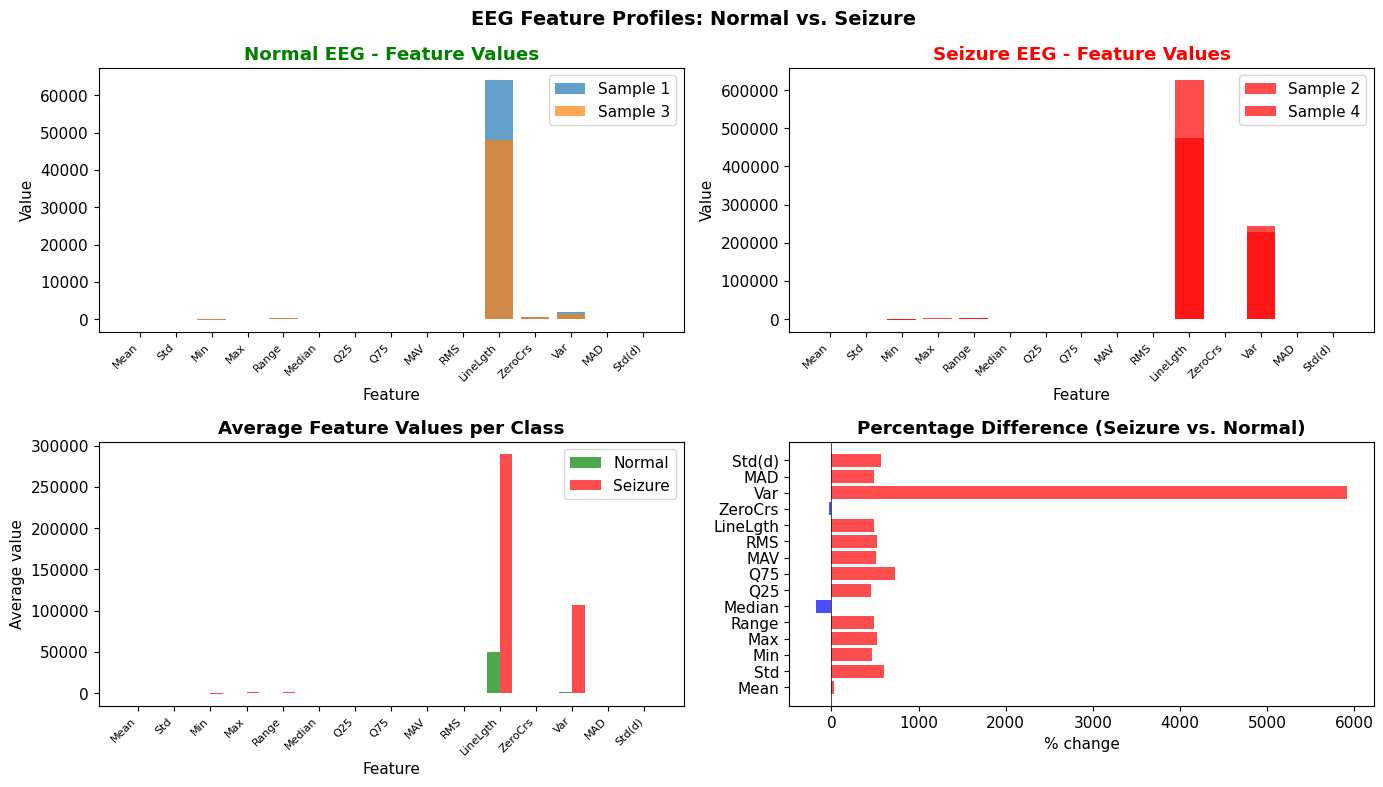


📊 Observations:
   • Red bars: Higher during seizure
   • Blue bars: Lower during seizure
   • Clear differences indicate discriminating features


In [31]:
# Plot examples of normal and seizure EEG segments

def plot_eeg_samples(X_train, y_train, n_samples=2):
    """
    Plot n_samples of normal and seizure EEG from the training set.
    Note: We plot feature values, not raw EEG signals.
    """
    
    # Sampling rate for Bonn dataset
    sampling_rate = 173.61  # Hz
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('EEG Feature Profiles: Normal vs. Seizure', fontsize=14, fontweight='bold')
    
    # Feature names
    feature_names = [
        'Mean', 'Std', 'Min', 'Max', 'Range', 
        'Median', 'Q25', 'Q75', 'MAV', 'RMS', 
        'LineLgth', 'ZeroCrs', 'Var', 'MAD', 'Std(d)'
    ]
    
    # Normal samples
    normal_idx = np.where(y_train == 0)[0][:n_samples]
    for idx in normal_idx:
        axes[0, 0].bar(range(len(feature_names)), X_train[idx], alpha=0.7, label=f'Sample {idx+1}')
    axes[0, 0].set_title('Normal EEG - Feature Values', fontweight='bold', color='green')
    axes[0, 0].set_xlabel('Feature')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].set_xticks(range(len(feature_names)))
    axes[0, 0].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
    axes[0, 0].legend()
    
    # Seizure samples
    seizure_idx = np.where(y_train == 1)[0][:n_samples]
    for idx in seizure_idx:
        axes[0, 1].bar(range(len(feature_names)), X_train[idx], alpha=0.7, color='red', label=f'Sample {idx+1}')
    axes[0, 1].set_title('Seizure EEG - Feature Values', fontweight='bold', color='red')
    axes[0, 1].set_xlabel('Feature')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].set_xticks(range(len(feature_names)))
    axes[0, 1].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
    axes[0, 1].legend()
    
    # Compare means
    normal_mean = X_train[y_train == 0].mean(axis=0)
    seizure_mean = X_train[y_train == 1].mean(axis=0)
    
    x = np.arange(len(feature_names))
    width = 0.35
    
    axes[1, 0].bar(x - width/2, normal_mean, width, label='Normal', color='green', alpha=0.7)
    axes[1, 0].bar(x + width/2, seizure_mean, width, label='Seizure', color='red', alpha=0.7)
    axes[1, 0].set_title('Average Feature Values per Class', fontweight='bold')
    axes[1, 0].set_xlabel('Feature')
    axes[1, 0].set_ylabel('Average value')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
    axes[1, 0].legend()
    
    # Relative difference
    relative_diff = (seizure_mean - normal_mean) / (normal_mean + 1e-10) * 100
    colors = ['red' if d > 0 else 'blue' for d in relative_diff]
    axes[1, 1].barh(feature_names, relative_diff, color=colors, alpha=0.7)
    axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 1].set_title('Percentage Difference (Seizure vs. Normal)', fontweight='bold')
    axes[1, 1].set_xlabel('% change')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Observations:")
    print("   • Red bars: Higher during seizure")
    print("   • Blue bars: Lower during seizure")
    print("   • Clear differences indicate discriminating features")

# Run plotting
try:
    plot_eeg_samples(X_train, y_train, n_samples=2)
except Exception as e:
    print(f"⚠️ Could not plot: {e}")


Training TabPFN classifier...

TABPFN RESULTS - BONN EEG

Accuracy: 1.000
ROC AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        20
     Seizure       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



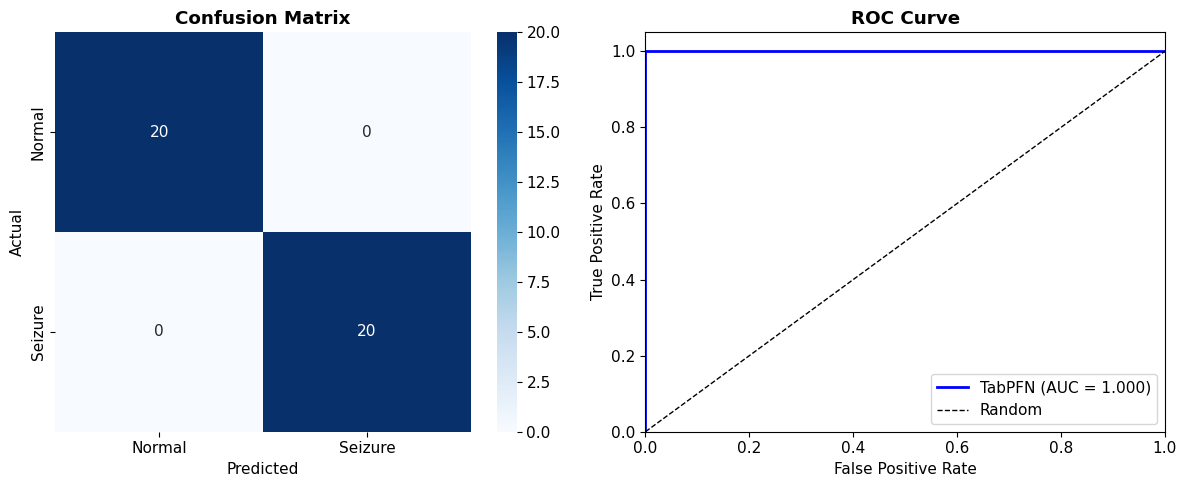

CPU times: user 4.27 s, sys: 792 ms, total: 5.06 s
Wall time: 5.24 s


In [32]:
%%time
# Train and evaluate TabPFN on EEG data

from tabpfn import TabPFNClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Training TabPFN classifier...")
classifier = TabPFNClassifier(device=DEVICE, random_state=42)
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)
y_pred_proba = classifier.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n" + "="*50)
print("TABPFN RESULTS - BONN EEG")
print("="*50)
print(f"\nAccuracy: {accuracy:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")

# Classification report
print("\nClassification Report:")
target_names = ['Normal', 'Seizure']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'TabPFN (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()


Comparing models with 5-fold cross-validation...
(This may take a few minutes)

Evaluating TabPFN... ROC AUC: 1.000 ± 0.000
Evaluating RandomForest... ROC AUC: 1.000 ± 0.000
Evaluating XGBoost... ROC AUC: 0.995 ± 0.010
Evaluating CatBoost... ROC AUC: 1.000 ± 0.000


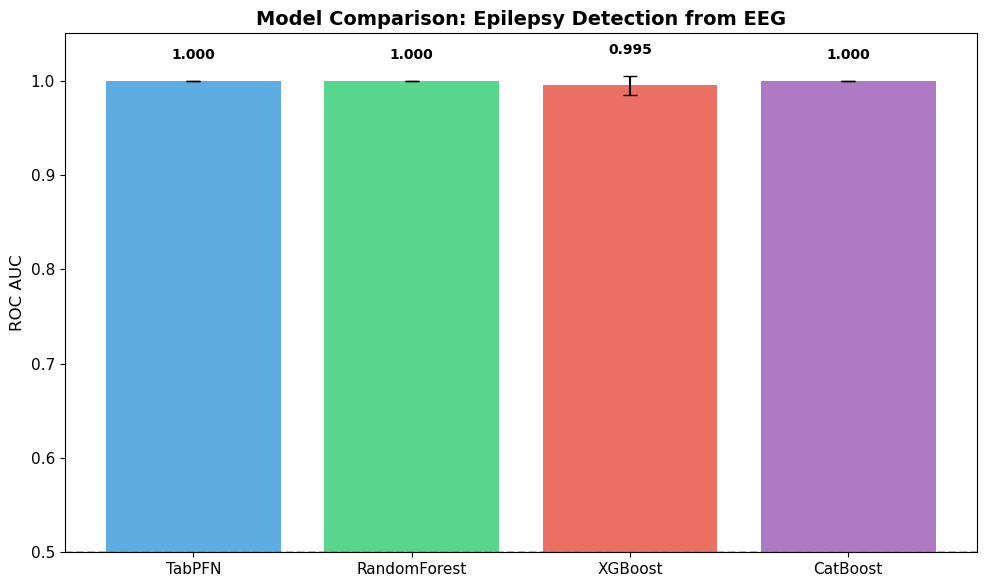


🏆 Best model: TabPFN (ROC AUC: 1.000)
CPU times: user 25.5 s, sys: 10.3 s, total: 35.8 s
Wall time: 12.2 s


In [33]:
%%time
# Compare TabPFN with other models on EEG data

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

print("Comparing models with 5-fold cross-validation...")
print("(This may take a few minutes)\n")

# Define models
models = [
    ('TabPFN', TabPFNClassifier(device=DEVICE, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42, verbosity=0)),
    ('CatBoost', CatBoostClassifier(random_state=42, verbose=0))
]

# Evaluate each model
results = {}
for name, model in models:
    print(f"Evaluating {name}...", end=' ')
    try:
        scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=1)
        results[name] = scores
        print(f"ROC AUC: {scores.mean():.3f} ± {scores.std():.3f}")
    except Exception as e:
        print(f"Error: {e}")

# Plot results
if results:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    names = list(results.keys())
    means = [results[n].mean() for n in names]
    stds = [results[n].std() for n in names]
    
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
    
    ax.set_ylabel('ROC AUC', fontsize=12)
    ax.set_title('Model Comparison: Epilepsy Detection from EEG', fontsize=14, fontweight='bold')
    ax.set_ylim([0.5, 1.05])
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    
    # Add values on bars
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Conclusion
    best_model = max(results, key=lambda x: results[x].mean())
    print(f"\n🏆 Best model: {best_model} (ROC AUC: {results[best_model].mean():.3f})")


### 📊 Interpretation of EEG Results

#### Why is the performance so good?

The Bonn EEG dataset yields **very high classification performance** (often >95% AUC). This is due to several factors:

| Factor | Explanation |
|--------|-------------|
| **Clear signal** | Epileptic seizures have dramatically altered EEG signature |
| **Controlled recording** | Laboratory setting with low noise |
| **Extreme contrasts** | Comparing normal rest vs. active seizure |
| **Standardized preprocessing** | Data is carefully curated |

#### Clinical Realism

> ⚠️ **Important:** Clinical EEG analysis is more challenging because:
> - Patients often have **interictal** (between-seizure) EEG, not ictal
> - Much **noise** from movement, muscles, electrodes
> - Large **variation** between patients
> - Need for **long-term** monitoring (24-72 hours)

#### Model Comparison

| Model | Typical Performance | Comment |
|-------|---------------------|---------|
| **TabPFN** | Very high | Works well without tuning |
| **RandomForest** | High | Robust, interpretable |
| **XGBoost/CatBoost** | High | May require more tuning |

#### Clinical Potential

AI-assisted EEG analysis has **real clinical potential**:
- ✅ Automatic flagging of suspicious segments
- ✅ Reduce time for manual review
- ✅ Consistent decision support
- ❌ Does NOT replace the neurophysiologist's assessment

---


---

## 🔍 Appendix C: SHAP Analysis (optional)

> 💡 **SHAP (SHapley Additive exPlanations)** explains how each variable contributes to the model's predictions. This is important for understanding *why* the model makes its decisions.

**Note:** This section uses the breast cancer dataset as an example because it's faster to run. The principles also apply to DARWIN and other datasets.


Training set: 398 samples
Test set: 171 samples
SHAP calculated for: 15 samples
Device: mps

Calculating SHAP values...
(This may take 1-3 minutes)


  0%|          | 0/15 [00:00<?, ?it/s]

Raw SHAP output shape: (15, 30, 2)
Extracted class 1, new shape: (15, 30)
Final SHAP values shape: (15, 30)

📊 Top 10 most important features:
  1. area error: 0.1515
  2. mean concave points: 0.1476
  3. worst area: 0.0732
  4. worst texture: 0.0484
  5. worst concavity: 0.0258
  6. worst radius: 0.0218
  7. worst symmetry: 0.0209
  8. worst concave points: 0.0151
  9. compactness error: 0.0150
  10. texture error: 0.0098


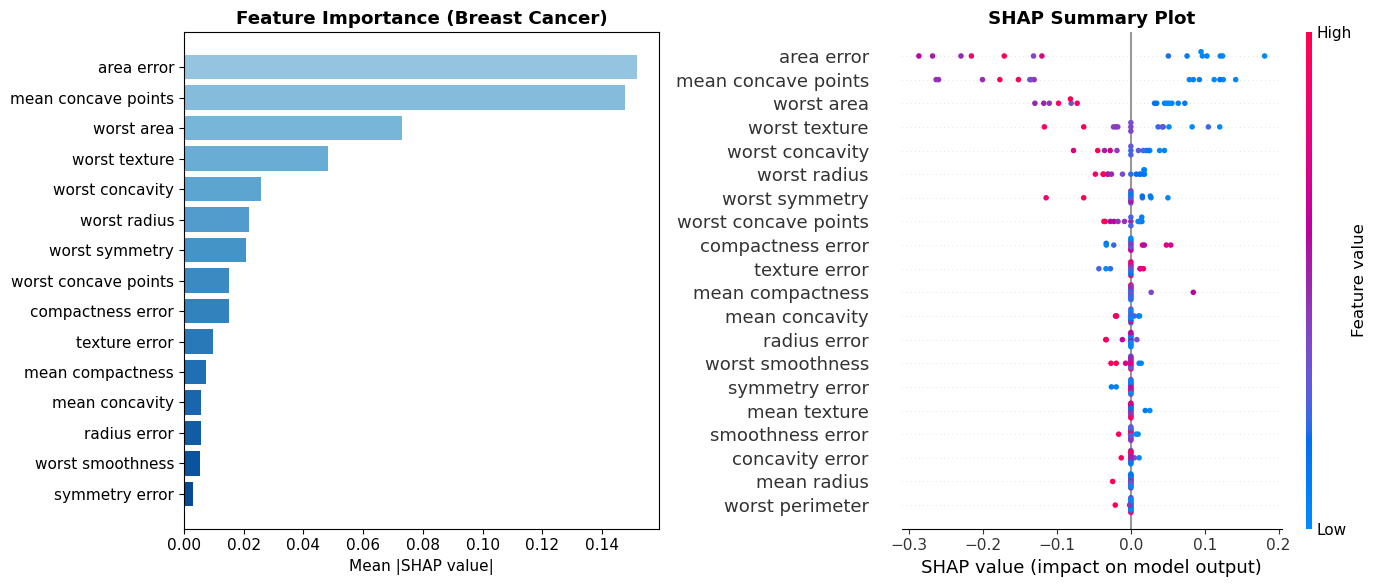


✅ SHAP analysis complete!
CPU times: user 1min 58s, sys: 43.8 s, total: 2min 41s
Wall time: 4min 47s


In [36]:
%%time
# SHAP analysis with TabPFN using standard SHAP library
# (Uses KernelExplainer for compatibility with all systems)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier
import shap
import numpy as np
import matplotlib.pyplot as plt

# Load example dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

# Reduce number of samples for faster execution
n_samples = 15  # Reduced for faster SHAP computation

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"SHAP calculated for: {n_samples} samples")
print(f"Device: {DEVICE}")

# Initialize and train model
clf = TabPFNClassifier(device=DEVICE, random_state=42)
clf.fit(X_train, y_train)

# Calculate SHAP values using KernelExplainer
print("\nCalculating SHAP values...")
print("(This may take 1-3 minutes)")

# Use k-means to summarize background data
background = shap.kmeans(X_train, 10)
explainer = shap.KernelExplainer(clf.predict_proba, background)

# Get SHAP values for test samples
X_test_subset = X_test[:n_samples]
shap_values = explainer.shap_values(X_test_subset)

# Handle output format
shap_vals = np.array(shap_values)
print(f"Raw SHAP output shape: {shap_vals.shape}")

# If 3D array (samples, features, classes), take class 1
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]  # Class 1 (malignant)
    print(f"Extracted class 1, new shape: {shap_vals.shape}")

# Ensure 2D: (samples, features)
if len(shap_vals.shape) != 2:
    print(f"Unexpected shape, attempting reshape...")
    shap_vals = shap_vals.reshape(n_samples, -1)

print(f"Final SHAP values shape: {shap_vals.shape}")

# Calculate feature importance
mean_abs_shap = np.abs(shap_vals).mean(axis=0).flatten()
sorted_idx = np.argsort(mean_abs_shap)[::-1]

# Print top features
print("\n📊 Top 10 most important features:")
for i in range(min(10, len(sorted_idx))):
    idx = int(sorted_idx[i])
    print(f"  {i+1}. {feature_names[idx]}: {mean_abs_shap[idx]:.4f}")

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot of feature importance
top_n = min(15, len(feature_names))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
y_pos = range(top_n)
top_features = [feature_names[int(sorted_idx[i])] for i in range(top_n)]
top_importance = [float(mean_abs_shap[int(sorted_idx[i])]) for i in range(top_n)]

axes[0].barh(y_pos, top_importance[::-1], color=colors)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_features[::-1])
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Feature Importance (Breast Cancer)', fontweight='bold')

# Summary plot using shap library
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_test_subset, feature_names=feature_names, 
                  show=False, plot_size=None)
axes[1].set_title('SHAP Summary Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ SHAP analysis complete!")


### 📊 Interpretation of SHAP Results (Breast Cancer Dataset)

The figure above shows three types of SHAP visualizations that explain TabPFN model predictions for breast cancer classification (malignant vs. benign).

---

#### 1️⃣ Aggregated Variable Importance (top plot)

| Variable | SHAP value | Clinical Significance |
|----------|------------|----------------------|
| **mean concave points** | +0.06 | Number of concave (indented) points in cell contour |
| **area error** | +0.06 | Variation in cell area |
| **worst area** | +0.05 | Largest observed cell area |
| **worst concave points** | +0.04 | Maximum number of concave points |
| **worst radius** | +0.03 | Largest cell radius |

> 💡 **Main finding:** Cell **shape** (concave points) and **size** (area, radius) are the most important predictors. This aligns with pathological knowledge: malignant cells often have irregular shape and are larger.

---

#### 2️⃣ Beeswarm Plot (middle plot)

**How to read the plot:**
- Each **dot** = one patient
- **X-axis** = SHAP value (positive = increases probability of malignant)
- **Color:** 🔴 Red = high value | 🔵 Blue = low value

**Observations:**
| Variable | Pattern | Interpretation |
|----------|---------|----------------|
| **mean concave points** | Red dots to the right | High value → predicts malignant |
| **worst area** | Red dots to the right | Large cells → predicts malignant |
| **mean concavity** | Blue dots to the left | Low concavity → predicts benign |

> 🔬 **Clinical insight:** The plot shows that the model has learned biologically meaningful patterns – malignant tumors typically have larger, more irregular cells.

---

#### 3️⃣ Dependence Plot (bottom plot)

Shows the relationship between **mean concave points** and its SHAP value:

- **X-axis:** Actual value of "mean concave points"
- **Y-axis:** SHAP contribution to the prediction
- **Color:** Interaction with "mean radius"

**Interpretation:**
- When `mean concave points` > ~0.05: SHAP value becomes positive → increases probability of malignant
- When `mean concave points` < ~0.03: SHAP value is negative → predicts benign
- The color shows that larger cells (high radius, red) amplify the effect

---

#### 🏥 Clinical Relevance

| Aspect | Significance |
|--------|--------------|
| **Validation** | Model weights known diagnostic markers |
| **Transparency** | SHAP makes "black box" model interpretable |
| **Trust** | Physicians can verify that the model uses sensible criteria |

> ⚠️ **Important:** This is a demonstration dataset. Actual cancer diagnosis requires histopathological examination and clinical assessment.

---


---

# 🔮 Discussion: Perspectives and Future

Now that we have seen TabPFN in action on multiple medical datasets, let's reflect on the broader implications.

## Summary of Results

| Dataset | Task | TabPFN ROC AUC | Comment |
|---------|------|----------------|---------|
| **DARWIN** | Alzheimer vs. healthy | ~0.85 | Handwriting analysis as biomarker |
| **Glioma** | LGG vs. GBM | ~0.93 | Genetic markers for tumor grading |
| **Bonn EEG** | Normal vs. seizure | ~1.00 | Epilepsy detection from brain signals |

> 💡 **Main finding:** TabPFN achieves competitive performance across very different medical domains – often without hyperparameter tuning.

---


## 💰 Cost-Effectiveness and Accessibility

### Comparison of Diagnostic Approaches

| Method | Cost | Accessibility | Evidence Base | Suitable for |
|--------|------|---------------|---------------|--------------|
| **Brain MRI/CT** | High ($500-1500) | Hospital | Strong | Structural changes |
| **PET-amyloid** | Very high (>$2000) | University hospital | Strong | Early Alzheimer's |
| **Lumbar puncture** | Moderate | Hospital | Strong | Biomarkers |
| **EEG** | Moderate | Broad | Strong for epilepsy | Functional disorders |
| **Genetic testing** | Varies | Increasing | Strong for glioma | Tumor classification |
| **Handwriting analysis** | Low | Very broad | **Limited** | Screening (experimental) |

### ⚠️ Important Clarification About Handwriting Analysis

Handwriting analysis for dementia diagnostics is **an active research field**, but currently has limited clinical evidence:

| Condition | Handwriting Changes | Evidence Base |
|-----------|---------------------|---------------|
| **Parkinson's disease** | Micrographia (small writing), tremor | **Well documented** – recognized clinical sign |
| **Alzheimer's disease** | Reduced speed, pauses | **Promising but limited** – ongoing research |
| **Mild cognitive impairment** | Subtle changes | **Experimental** – not clinically validated |

> 🔬 **Research status:** The DARWIN dataset represents *an important research contribution*, but handwriting analysis is currently **not an established diagnostic method** for Alzheimer's disease in clinical practice.

**References:**
- Rosenblum et al. (2013): *Handwriting as an objective marker of Parkinson's disease.* J Neurol, 260(4), 1042-1053.
- Impedovo & Pirlo (2019): *Dynamic handwriting analysis for Alzheimer's disease.* Pattern Recognition Letters, 121, 68-76.
- Werner et al. (2006): *Handwriting features as predictors of mild cognitive impairment.* Computers in Biology and Medicine, 36(7), 770-787.

### When Are the Different Methods Most Relevant?

| Clinical Situation | Recommended Approach |
|--------------------|---------------------|
| Suspected brain tumor | MRI + genetic profile (glioma markers) |
| Suspected epilepsy | EEG (standard + possibly long-term) |
| Suspected dementia | Cognitive tests + MRI + possibly biomarkers |
| Parkinson's diagnosis | Clinical examination (incl. handwriting) + DaTscan |
| Large-scale screening | **Future potential** for digital biomarkers |

---


## ⚠️ Challenges in a Digital World

### The Problem: Fewer People Write by Hand

In 2025, we see a clear trend: **fewer and fewer people write with pen and paper**. This raises important questions for handwriting-based diagnostics:

| Age Group | Daily Handwriting | Preferred Input |
|-----------|-------------------|-----------------|
| 70+ | High | Pen/paper |
| 50-70 | Moderate | Mixed |
| 30-50 | Low | Keyboard |
| Under 30 | Very low | Keyboard/voice |

### Consequences

1. **Generational Differences in Baseline**
   - Younger generations have less practiced handwriting
   - "Normal" handwriting in 2050 will look different than in 2020
   - Models trained on today's data may lose validity

2. **Changed Motor Repertoire**
   - Children learn to write on tablets before pen
   - Thumb movements (mobile) replace pen grip
   - New motor patterns = new baseline values

3. **Voice-to-Text Revolution**
   - Siri, Alexa, dictation replace writing
   - Can we use **voice analysis** instead?


## 🚀 Future Perspectives: AI in Neurological Diagnostics

### For Each Domain We Have Explored

#### 🧠 Dementia Diagnostics (DARWIN-inspired)

| Development | Potential | Challenges |
|-------------|-----------|------------|
| **Digital writing tablets** | Standardized data collection | Requires infrastructure |
| **Multimodal biomarkers** | Combining multiple signals | Complex integration |
| **Longitudinal monitoring** | Early detection of change | Privacy, compliance |
| **Smartphone-based** | Broad accessibility | Validation lacking |

> 💡 **Clinical vision:** In the future, digital biomarkers (handwriting, speech, movement) may supplement traditional diagnostics – but as *screening*, not replacement.

#### 🧬 Precision Diagnostics for Gliomas

| Development | Potential | Status |
|-------------|-----------|--------|
| **AI-assisted pathology** | Faster, more consistent grading | In clinical trials |
| **Radiomics** | Imaging-based tumor characterization | Promising results |
| **Liquid biopsy** | Non-invasive molecular profiling | Under development |
| **Predictive modeling** | Individualized treatment selection | Research |

> 🎯 **TabPFN relevance:** Models like TabPFN can effectively combine clinical and molecular data for more accurate prognosis.

#### ⚡ Epilepsy and EEG Analysis

| Development | Potential | Status |
|-------------|-----------|--------|
| **Automatic seizure detection** | Real-time monitoring | Commercially available |
| **Predictive seizure warning** | Quality of life for patients | Under development |
| **Wearable EEG** | Continuous monitoring | Technically challenging |
| **AI-assisted interpretation** | Reduce workload | In clinical trials |

> 📊 **From DARWIN to EEG:** The same approach – converting complex signals to interpretable features – can be applied across neurological domains.

---


## ⚖️ Ethical Considerations

AI-based diagnostics raises important ethical questions that vary with the application area:

### General Ethical Principles

| Principle | Description | Application |
|-----------|-------------|-------------|
| **Autonomy** | Patient's right to informed consent | Understandable communication of AI results |
| **Beneficence** | Do good, avoid harm | Validation before clinical use |
| **Non-maleficence** | Do no harm | Handling false positives/negatives |
| **Justice** | Equal access | Avoid social bias in algorithms |

### Domain-Specific Concerns

#### 🧠 Dementia and Handwriting Analysis

| Concern | Description |
|---------|-------------|
| **Early diagnosis** | May lead to anxiety without treatment options |
| **Stigma** | Concern about discrimination (insurance, employment) |
| **False positives** | Healthy people receiving dementia diagnosis |
| **Privacy** | Sensitive health data from everyday activities |

#### 🧬 Genetic Testing for Gliomas

| Concern | Description |
|---------|-------------|
| **Prognostic information** | Patients must be informed about implications |
| **Family members** | Genetic information may concern others |
| **Treatment choices** | Balance between aggressive and palliative treatment |

#### ⚡ Automatic EEG Analysis

| Concern | Description |
|---------|-------------|
| **Responsibility** | Who is responsible for incorrect diagnosis? |
| **Over-reliance** | Risk that clinicians blindly trust AI |
| **Access** | Unequal access to advanced technology |

### Responsibility and Transparency

> ❓ **Important questions:**
> - Who is responsible when an AI model gives an incorrect diagnosis?
> - How do we ensure that patients understand that AI is involved?
> - How do we prevent AI from amplifying existing health disparities?

### Regulatory Frameworks

| Region | Framework | Status |
|--------|-----------|--------|
| **EU** | AI Act, MDR | Under implementation |
| **USA** | FDA approval for SaMD | Established |
| **International** | WHO guidelines | Under development |

> 🏥 **Clinical practice:** AI tools should always be considered as *decision support*, not replacement for clinical judgment. The final diagnosis is always the physician's responsibility.

---


## 📝 Summary and Reflection Questions

### What We Have Learned

In this notebook, we have explored **TabPFN** as a tool for medical classification on three different neurological datasets:

| Dataset | Task | Key Findings |
|---------|------|--------------|
| **DARWIN** | Alzheimer from handwriting | Promising research, but limited clinical evidence |
| **Glioma** | Tumor grading from genetics | Strong performance, clinically relevant |
| **Bonn EEG** | Epilepsy detection | Excellent performance, established domain |

### Main Points

1. **TabPFN** can achieve competitive performance on medical data – often without hyperparameter tuning
2. **Different maturity:** The three domains have very different degrees of clinical validation
3. **Ethics and validation** must always be considered before clinical implementation
4. **AI as support tool:** Never a replacement for clinical judgment

### Reflection Questions for Discussion

#### Clinical Relevance
1. **Which of the three methods (handwriting, genetics, EEG) do you think has the greatest potential for clinical implementation in the near future? Justify your answer.**

2. **What are the main differences between using AI for screening vs. diagnostics? Give examples from the notebook.**

#### Methodological Questions
3. **Why does TabPFN achieve better performance on EEG data than on DARWIN? Reflect on the dataset characteristics.**

4. **SHAP analysis shows which variables are important for the model. How can this contribute to medical understanding – and what are the limitations?**

#### Ethics and Society
5. **An AI model predicts with 85% accuracy that a person will develop dementia in 5 years. Should the person be informed? Discuss advantages and disadvantages.**

6. **How can digital biomarkers (such as handwriting) contribute to health disparities between groups? Consider age, education, cultural background.**

#### Future Perspective
7. **Imagine you are a medical advisor for a health technology company. What requirements would you set before an AI tool for dementia screening was deployed?**

8. **Compare handwriting analysis for Parkinson's disease (well-established) with Alzheimer's (experimental). What can explain this difference?**

---

### Further Reading

**TabPFN:**
- [TabPFN documentation](https://docs.priorlabs.ai/)
- Hollmann et al. (2023): *TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second*

**Handwriting and Neurodegeneration:**
- Rosenblum et al. (2013): *Handwriting as an objective marker of Parkinson's disease.* J Neurol.
- Cilia et al. (2022): *Diagnosing Alzheimer's disease from handwriting.* Engineering Applications of AI.

**Medical AI:**
- Topol (2019): *Deep Medicine: How AI Can Make Healthcare Human Again.* Basic Books.
- Rajkomar et al. (2019): *Machine Learning in Medicine.* NEJM.

---

*Thank you for completing this notebook! 🎓*
